#### Bibliotecas

In [1]:
# Bibliotecas
import numpy as np
import sys
import warnings
sys.path.append(r'C:\Users\Miyamura\Desktop\GIT_MESTRADO\ppgsi_comparable_mdp_risk\app')

# Problem Definition
from ppgsi_configuration_region.residuals.error_metrics import ErrorMetrics
from ppgsi_configuration_region.methods.value_function_factory import ValueFunctionFactory
from ppgsi_configuration_region.viz.mss_plots import MSSPlots

# Including Warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

# MSS - Multiple Sequential States Problem
---

Seja $n$ a quantidade de estados $\left\{ s_0, s_1, ..., s_n \right\}$ e cada estado possui uma ação $a_i$ com probabilidade $p_i$ de transicionar para o estado $s_{i+1}$ e probabilidade $(1-p_i)$ de retornar ao estado inicial $s_0$.

## Define Parâmetros
---

In [2]:
# ==================
# Definições Inicias
# ------------------
results = {}

# Custo por Ação
c = 1

# Probabilidade por Ação
p = 0.5
p0 = (1 - p)

# Quantidade de Estados
n = 3

# Numero de simulações
num_simulations = int(1e5)
np.random.seed = 42

# Parametros das metricas

# Parâmetros -------------------
# -- Exponential Utility Method.
# ------------------------------
vl_lambda = 0.01
_epsilon = int(1e-5)
_threshold = 1e4
_alpha = 0.99

EM_EXP = ErrorMetrics(_epsilon)

# Parâmetros -------------------
# -- Visualization
# ------------------------------
range_n = np.arange(1, 7, 1)
range_p = np.arange(0.1, 0.9, 0.05)

## Risk-Neutral
---
Value function formulation for MSS:

$$  $$

Analytical value function formulation for MSS:

$$ V^{n}(s_0) = \frac{c \sum_{i=0}^{n} p^{i}}{p^{n}} $$

In [3]:
rn_method = 'risk_neutral'
rn_obj = ValueFunctionFactory().get_calculator(method=rn_method)
results[rn_method] = {}

# 1.1. Simulacao
results[rn_method]['mss_value_function'], costs = rn_obj.mss_value_function(c, p, n, num_simulations)

# 1.2. Via Formula Analítica
results[rn_method]['mss_analytical_value_function'] = rn_obj.mss_analytical_value_function(c, p, n)

# Print results
print('1. Risk Neutral')
print('1.1. Valor via Simulacao:', results[rn_method]['mss_value_function'])
print('1.2. Valor via Formula Analitica:', results[rn_method]['mss_analytical_value_function'])

1. Risk Neutral
1.1. Valor via Simulacao: 14.11366
1.2. Valor via Formula Analitica: 14.0


## Exponential Utility Method
---

$$
    V^{\pi}(s_0) = e^{-\lambda c(s, \pi(s))} \sum_{s' \in \mathcal{S}} T(s, \pi(s), s') V^{\pi}(s')
$$

In [4]:
# Define metodos ---------------
# -- Exponential Utility Method.
# ------------------------------

# Criando objeto para Exponential Utility Function
exp_method = 'exponential_utility_function'
exp_obj = ValueFunctionFactory().get_calculator(method=exp_method)
results[exp_method] = {}

# MSS > Calcula Funcao Valor
results[exp_method]['mss_value_function'] = exp_obj.mss_value_function(n, p, c, vl_lambda, _threshold, _epsilon)
print('Algoritmo:', results[exp_method]['mss_value_function'])

# MSS > Calcula Formula analítica (se houver)
results[exp_method]['mss_analytical_value_function'] = exp_obj.mss_analytical_value_function(n, p, c, vl_lambda)
print('Analítico:', results[exp_method]['mss_analytical_value_function'])

Algoritmo: {0: 1.1591919355450424, 1: 1.136123630594449, 2: 1.090446087632029, 'sG': 1.0}
Analítico: {0: 1.1591919355450429}



              Calculando valores para os seguintes parâmetros:
                p: [0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75
 0.8  0.85] | 
                c: 1 | 
                lambda: 0.01 |
              


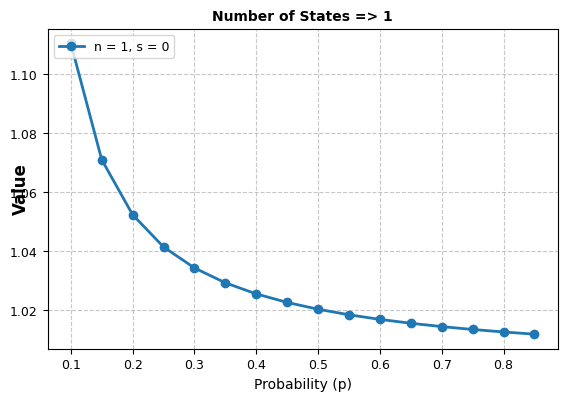

In [5]:
# OSMA > Calcula configuration region para cada probabilidade (p)
results[exp_method]['osma_value_function_range_probability'] = exp_obj.osma_value_function_range_probability(range_p, c, vl_lambda)
MSSPlots().subplots_for_number_of_states(results[exp_method]['osma_value_function_range_probability'], sharey=False)

In [6]:
# MSS > Calcula configuration region para cada numero de estado (n) e cada probabilidade (p)
results[exp_method]['mss_value_function_range_probability'] = exp_obj.mss_value_function_range_probability(range_n, range_p, c, vl_lambda, _threshold, _epsilon)

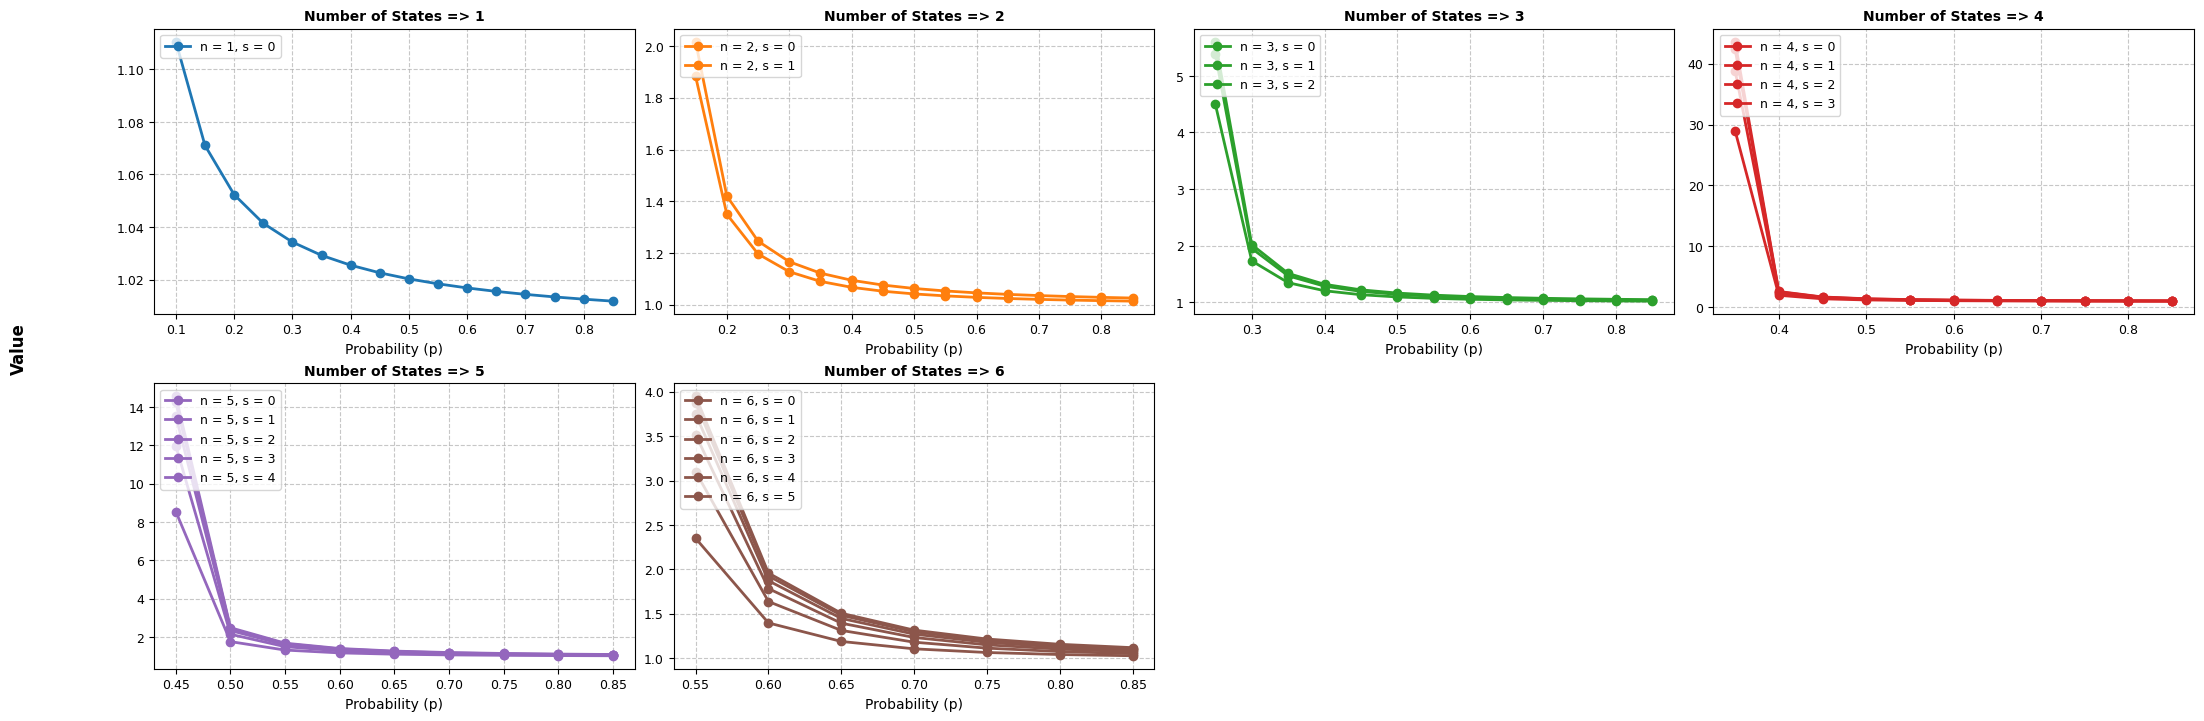

In [7]:
MSSPlots().subplots_for_number_of_states(results[exp_method]['mss_value_function_range_probability'], sharey=False, plot_only_first_state=False)

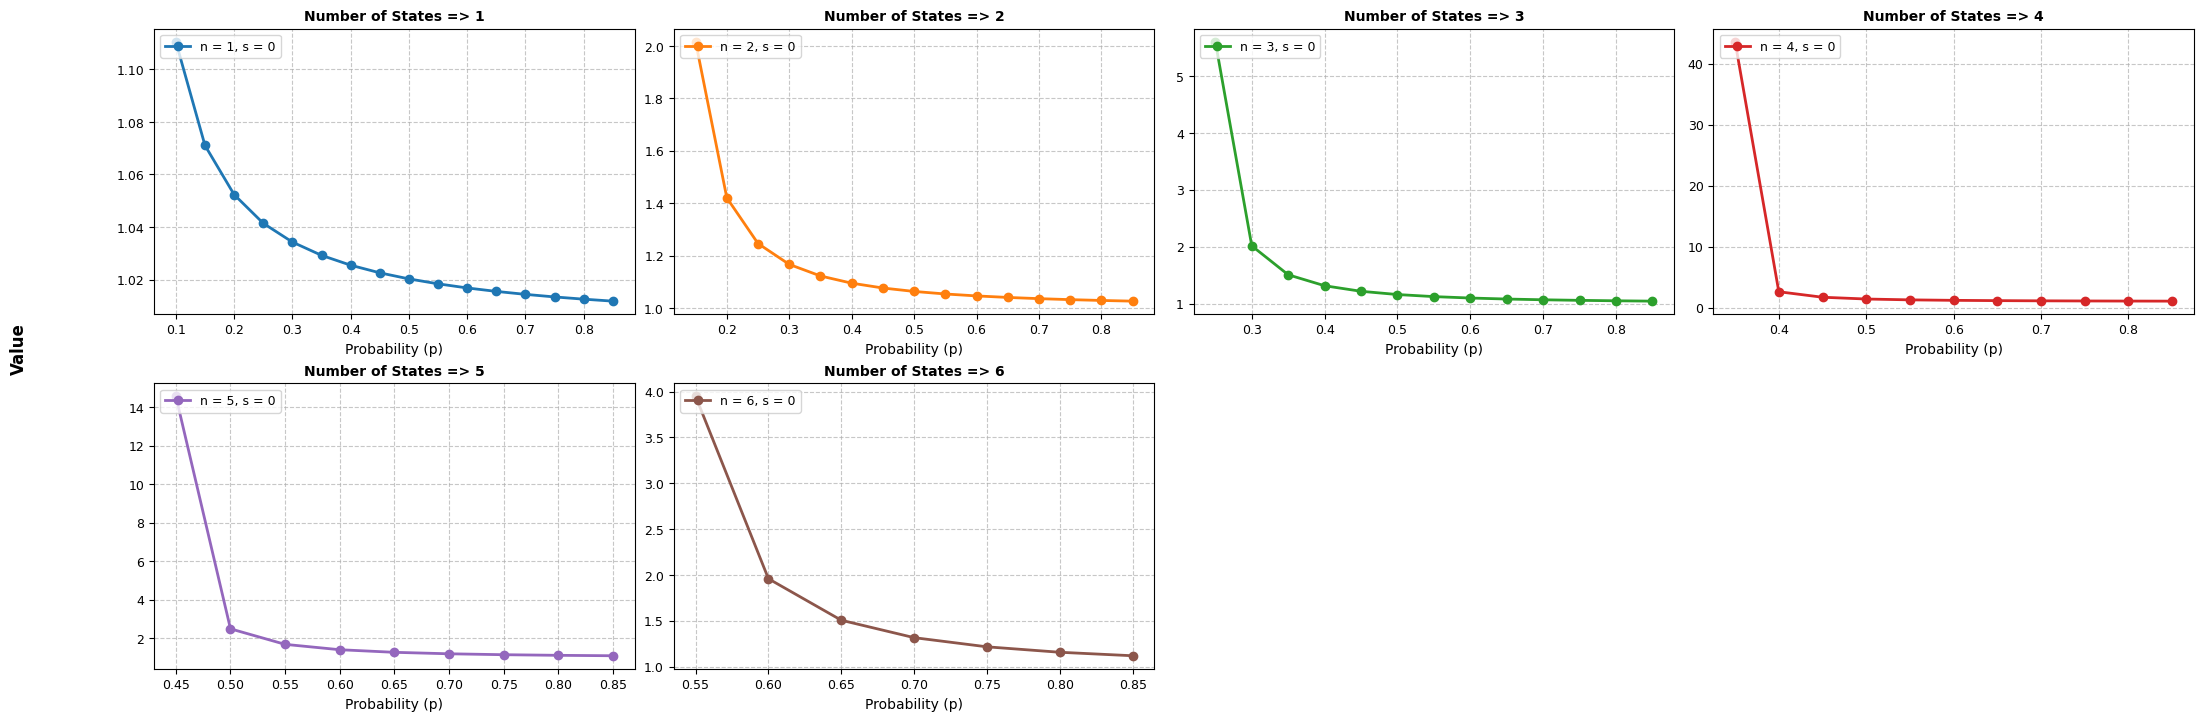

In [8]:
MSSPlots().subplots_for_number_of_states(results[exp_method]['mss_value_function_range_probability'], sharey=False, plot_only_first_state=True)

In [9]:
results[exp_method]['mss_analytical_value_function_range_probability'] = exp_obj.mss_analytical_value_function_range_probability(range_n, range_p, c, vl_lambda)

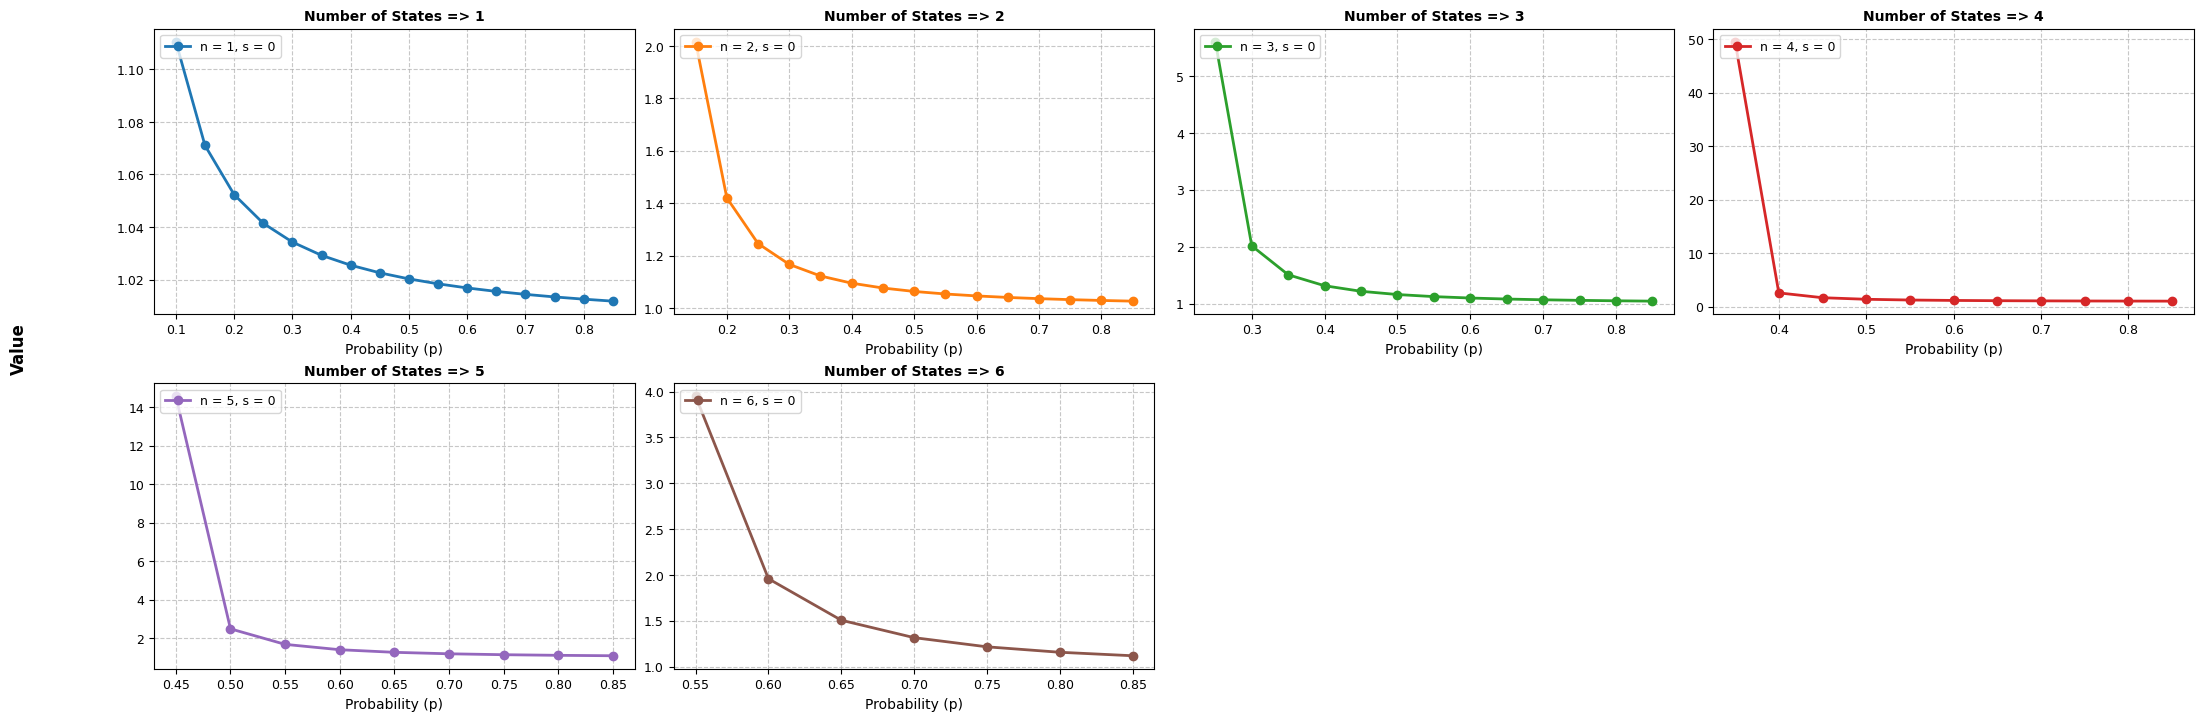

In [10]:
MSSPlots().subplots_for_number_of_states(results[exp_method]['mss_analytical_value_function_range_probability'], sharey=False, plot_only_first_state=True)

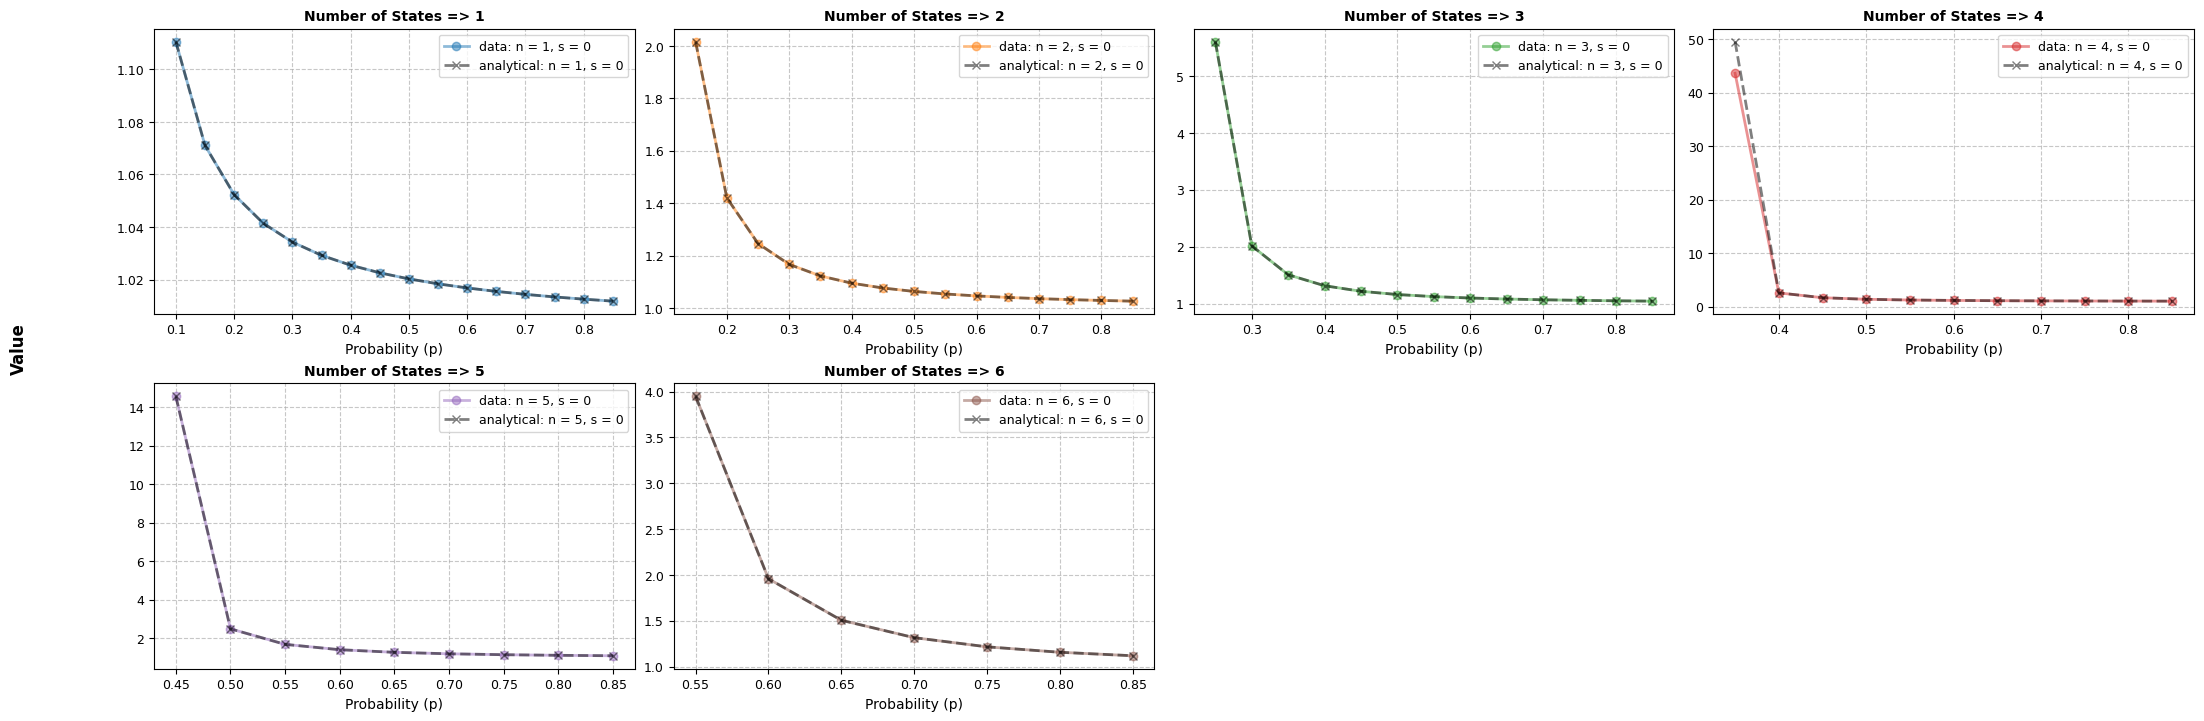

In [11]:
MSSPlots().compare_data_and_analytical(
    data=results[exp_method]['mss_value_function_range_probability'], 
    data_analytical=results[exp_method]['mss_analytical_value_function_range_probability'], 
    sharey=False, 
    plot_only_first_state=True
)

### Calculating Lambda-Extreme
---

In [12]:
# Calcual Lambda Extreme
# ----------------------
from ppgsi_configuration_region.methods.exponential_utility_function import LambdaExtreme
_le = LambdaExtreme()

_lambda_extreme_epsilon = 0.00001
_lambda_extreme_beta = 0.0001

In [13]:
# MSS > Calcula lambda extreme para um determinado n e um p
results[exp_method]['solver_lambda_extreme_mss'] = _le.solver_lambda_extreme_mss(n=3, p=0.5, c=c)
print('Lambda Extreme:', results[exp_method]['solver_lambda_extreme_mss'])

Lambda Extreme: {0: 0.08376931712393898}


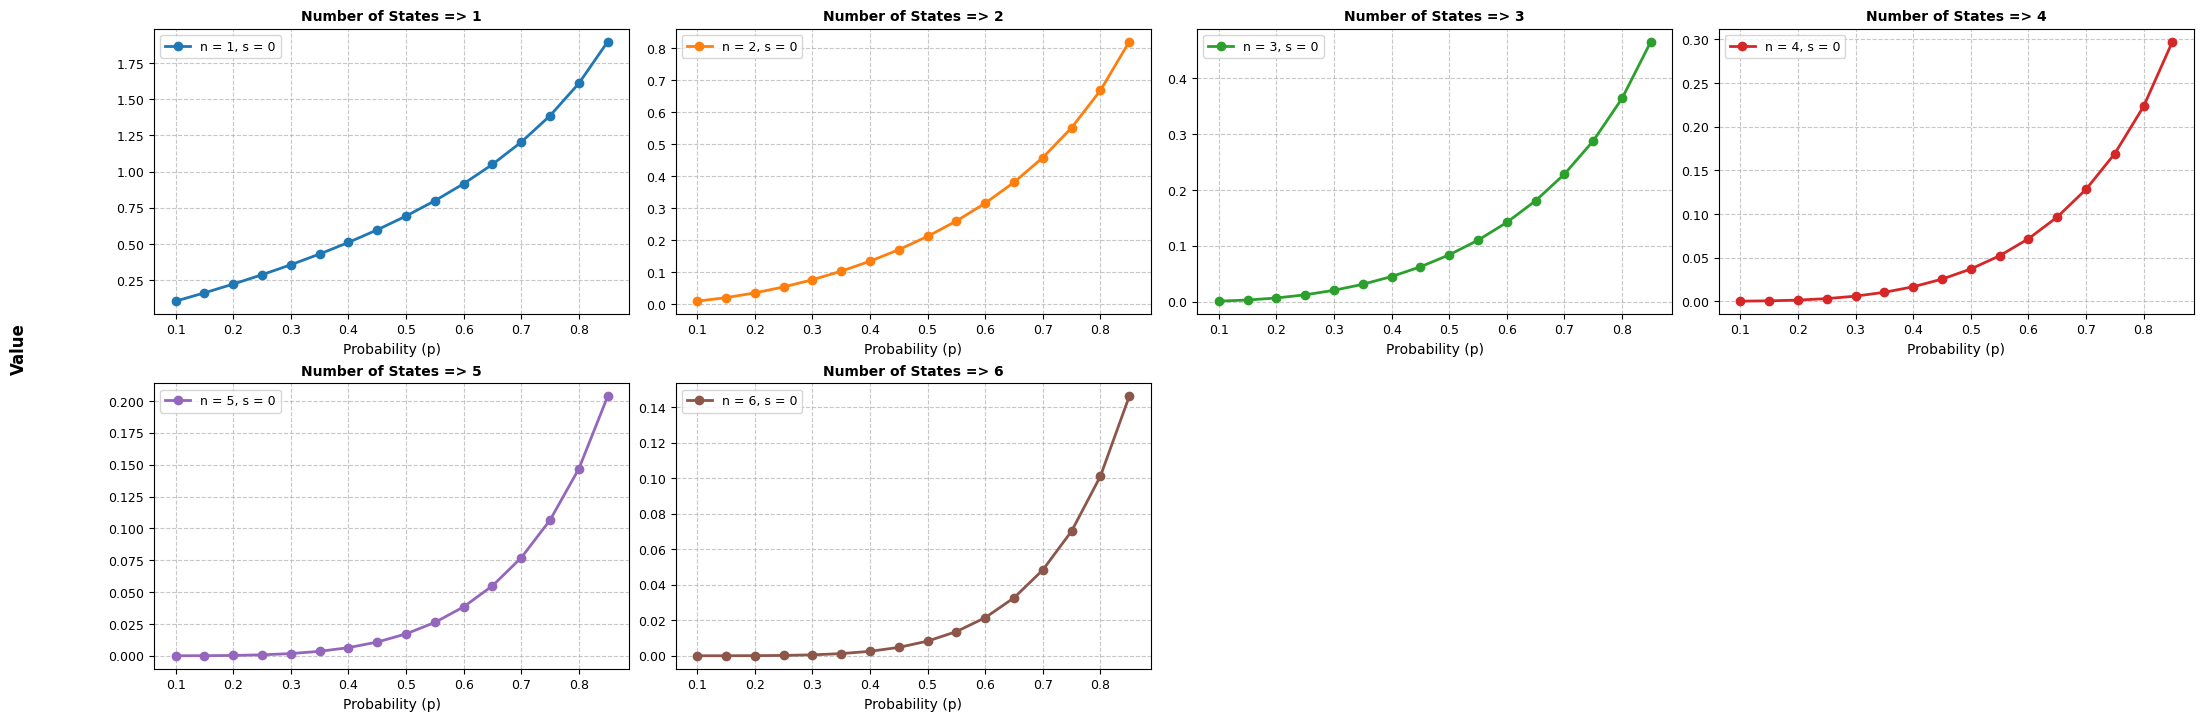

In [14]:
# MSS > Calcula lambda extreme para cada numero de estado (n) e cada probabilidade (p)
results[exp_method]['find_numerical_lambda_extreme_range_probability'] = _le.find_numerical_lambda_extreme_range_probability(n=range_n, p=range_p, c=c)
MSSPlots().subplots_for_number_of_states(results[exp_method]['find_numerical_lambda_extreme_range_probability'], sharey=False)

In [18]:
results[exp_method]['find_numerical_lambda_extreme_range_probability']

{1: {0.1: {0: 0.10536051565782628},
  0.15: {0: 0.16251892949777508},
  0.2: {0: 0.22314355131420935},
  0.25: {0: 0.28768207245178085},
  0.3: {0: 0.35667494393873234},
  0.35: {0: 0.430782916092454},
  0.4: {0: 0.5108256237659906},
  0.45: {0: 0.5978370007556204},
  0.5: {0: 0.6931471804545503},
  0.55: {0: 0.79850769621779},
  0.6: {0: 0.9162907318741549},
  0.65: {0: 1.0498221244986778},
  0.7: {0: 1.2039728043259108},
  0.75: {0: 1.3862943611198901},
  0.8: {0: 1.6094379124341005},
  0.85: {0: 1.8971199848858809}},
 2: {0.1: {0: 0.009209587038826746},
  0.15: {0: 0.020110790338582967},
  0.2: {0: 0.03491714485461199},
  0.25: {0: 0.05358859829963027},
  0.3: {0: 0.07620294844879384},
  0.35: {0: 0.10295250720454725},
  0.4: {0: 0.13415299760509947},
  0.45: {0: 0.17026550388280254},
  0.5: {0: 0.21193535550034195},
  0.55: {0: 0.2600562158572138},
  0.6: {0: 0.31587544720811955},
  0.65: {0: 0.3811725230949283},
  0.7: {0: 0.45857710050956346},
  0.75: {0: 0.5521791667674896},
  0

### Configuration Region for EUM (Exponential Utility Function)

--- 

In [62]:
from scipy.optimize import fsolve

guess_EC = 0
n = 4
p = 0.1
cr = 1
pr = 0.5

vl_lambda_extreme_reference = LambdaExtreme().solver_lambda_extreme_mss(n, pr, cr)[0]
vl_lambda_extreme = LambdaExtreme().solver_lambda_extreme_mss(n, p, cr)[0]
vl_lambda_extreme = min([vl_lambda_extreme, vl_lambda_extreme_reference])

vl_lambda = vl_lambda_extreme

print('Lambda:', vl_lambda)

def equation(EC, n, p, cr, pr, vl_lambda, _threshold, _epsilon, _alpha):
    # reference_values = exp_obj.mss_value_function(n, pr, cr, vl_lambda, _threshold, _epsilon, _alpha)
    reference_values = exp_obj.mss_analytical_value_function(n, pr, cr, vl_lambda)
    print('Reference:', reference_values)
    
    # values = exp_obj.mss_value_function(n, p, EC[0], vl_lambda, _threshold, _epsilon, _alpha)
    values = exp_obj.mss_analytical_value_function(n, p, EC, vl_lambda)
    print('Values:', values)
    
    return exp_obj.diff_dict_values(reference_values, values)

solution = fsolve(equation, guess_EC, args=(n, p, cr, pr, vl_lambda - 0.01, _threshold, _epsilon, _alpha))
solution

Lambda: 9.003647212919407e-05
Reference: {0: -0.7659448448840804}
Values: {0: array([-1.])}
Reference: {0: -0.7659448448840804}
Values: {0: array([-1.])}
Reference: {0: -0.7659448448840804}
Values: {0: array([-1.])}
Reference: {0: -0.7659448448840804}
Values: {0: array([-0.99999836])}
Reference: {0: -0.7659448448840804}
Values: {0: array([-0.81032532])}
Reference: {0: -0.7659448448840804}
Values: {0: array([-0.77588801])}
Reference: {0: -0.7659448448840804}
Values: {0: array([-0.76648262])}
Reference: {0: -0.7659448448840804}
Values: {0: array([-0.76595173])}
Reference: {0: -0.7659448448840804}
Values: {0: array([-0.76594485])}
Reference: {0: -0.7659448448840804}
Values: {0: array([-0.76594484])}
Reference: {0: -0.7659448448840804}
Values: {0: array([-0.76594484])}
Reference: {0: -0.7659448448840804}
Values: {0: array([-0.76594484])}


array([0.0027752])

In [68]:
results[exp_method]['run_configuration_region'] = exp_obj.run_configuration_region(n=range_n, p=range_p, cr=c, pr=pr, analytical=True, _threshold=_threshold, _epsilon=_epsilon)
# results[exp_method]['run_configuration_region']

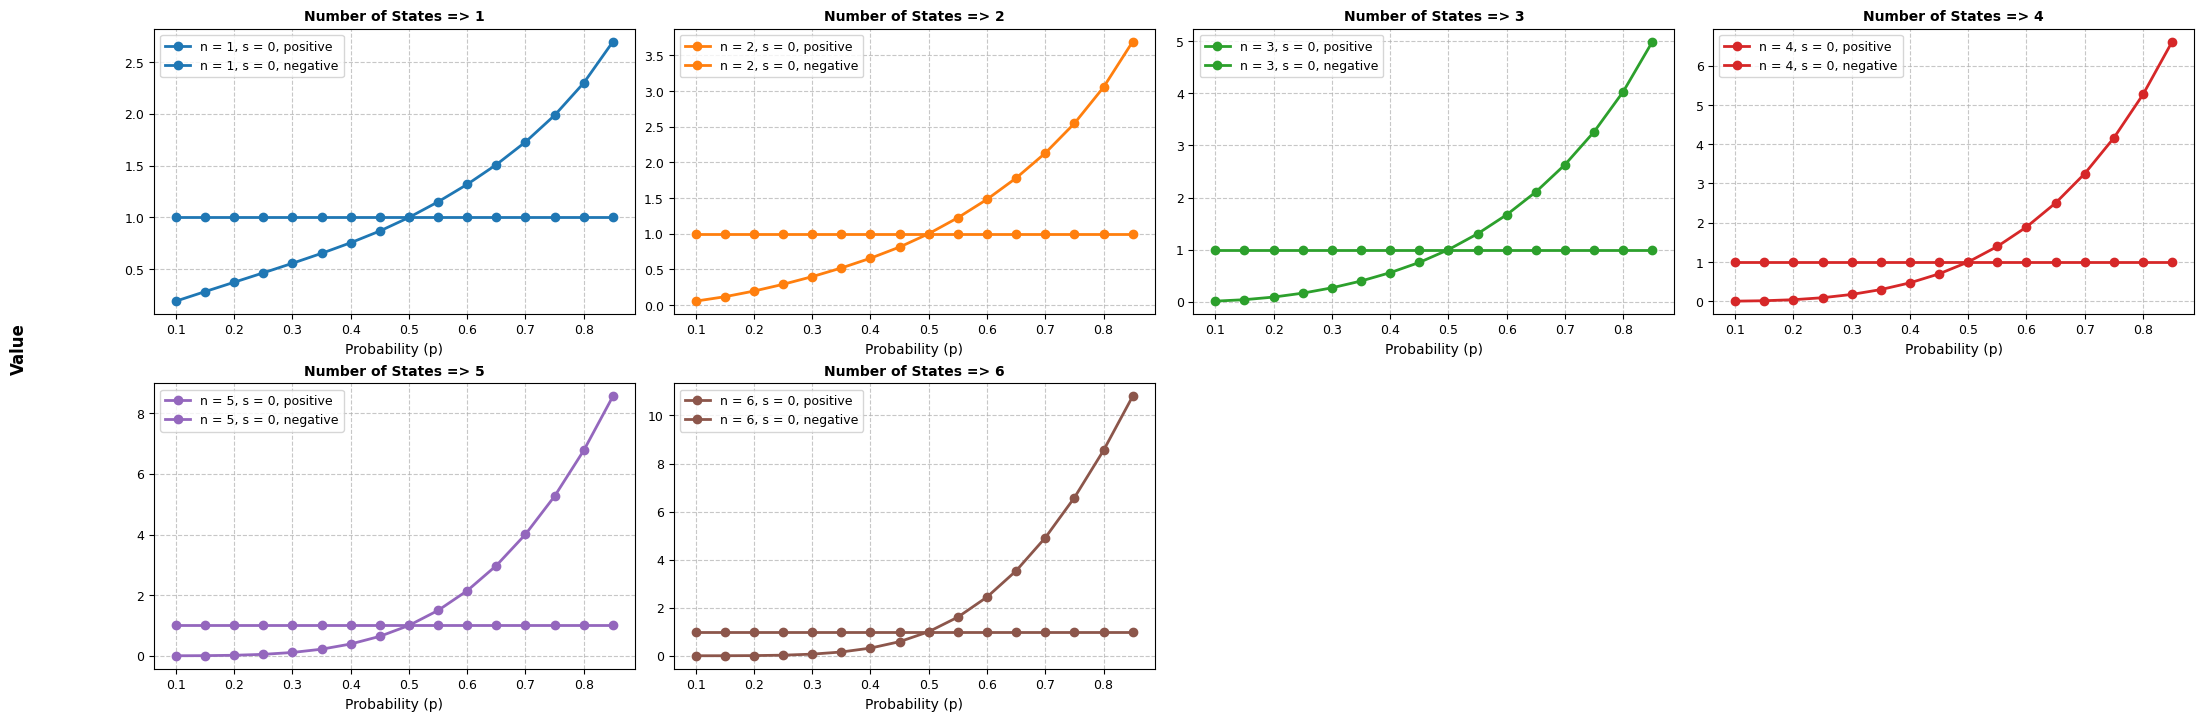

In [69]:
MSSPlots().plot_configuration_region(results[exp_method]['run_configuration_region'], sharey=False)

## Piecewise-linear Transformation
---

[Risk-Sensitive Piecewise-Linear Policy Iteration for Stochastic Shortest Path Markov Decision Processes] \
Formally, an infinity-horizon, an infinite-horizon RS-MDP is defined by a tuple $\langle M, k \rangle$, where $-1 < k < 1$ is the risk factor and $M$ is an infinite-horizon MDP. The approach proposed uses the piecewise-linear transformation function $\chi^{(k)}(x)$ which depends on the input $x$ (temporal difference) be it positive or not and on the risk factor $k$. This function is defined by:

$$
    \chi^{(k)}(x) =
        \begin{cases}
        (1 - k)x, & \text{if } x < 0, \\
        (1 + k)x, & \text{otherwise.}
        \end{cases}
$$

Given a stationary policy $\pi$, the corresponding value function $V_{k}^{\pi}(s)$ can be obtained by solving the following system of equations for all $s \in \mathcal{S}$:

$$
    \sum_{s' \in S} P(s' \mid s, \pi(s)) \chi^{(k)} \left( C(s, \pi(s), s') + \gamma V_k^{\pi}(s') - V_k^{\pi}(s) \right) = 0
$$

---

**Theorem 3.** If $k \in (-1, 1)$, $0 \leq \gamma < 1$ and $0 < \alpha \leq (1 + \mid k \mid)^{-1}$, the operator $O^{\pi}_{\alpha, k}[V]$ defined next is a contraction mapping:

$$
    O^{\pi}_{\alpha, k}[V](s) = V(s) + \alpha \sum_{s' \in \mathcal{S}} P(s' \mid s, \pi(s)) \chi^{(k)}(x)(C(s, \pi(s), s') + \gamma V(s') - V(s))
$$

i.e., for all functions $V_1$ and $V_2$, we have:
$
\lvert \mathcal{O}^{\pi}_{\alpha,k}[V_1] - \mathcal{O}^{\pi}_{\alpha,k}[V_2] \rvert 
\leq \rho \lvert V_1 - V_2 \rvert,
$
for some $\rho = (1 - \alpha (1 - \lvert k \rvert)(1 - \gamma)) \in (0, 1) < 1$.
The scalar $\alpha$ is a positive step-size.

In [185]:
# Parâmetros -------------------
# -- Exponential Utility Method.
# ------------------------------
k = 0.4
alpha = 0.3 # 1 / (1 + abs(k))
gamma = 1
_epsilon = 0.0001
_threshold = int(1e5)

In [186]:
# Criando objeto para Exponential Utility Function
plt_method = 'piecewise_linear_transformation'
plt_obj = ValueFunctionFactory().get_calculator(method=plt_method)
results[plt_method] = {}

# MSS > Value function
results[plt_method]['mss_value_function'], results[plt_method]['iterations'] = plt_obj.mss_value_function(2, p, c, k, alpha, gamma, _threshold, _epsilon, _verbose=False)
print('Value Function:', results[plt_method]['mss_value_function'])

Value Function: {0: 14.384860971343278, 1: 11.06694550715296, 'sG': 0.0}


In [187]:
# MSS > Analytical value function
plt_obj.mss_analytical_value_function(2, p, c, k)

{0: 14.444444444444443, 1: 11.111111111111109}


              Calculando valores para os seguintes parâmetros:
                p: [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85] | 
                c: 1 | 
                k: 0.4 |
              


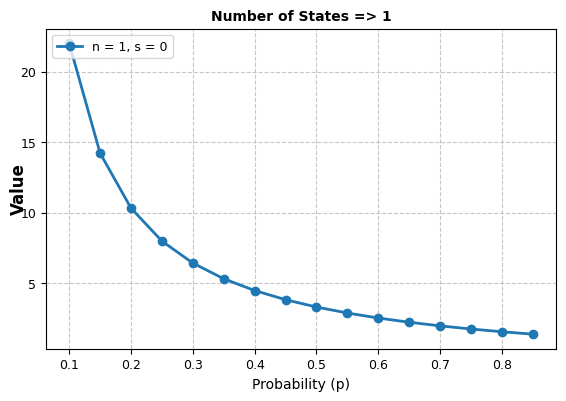

In [188]:
# OSMA > Value function
results[plt_method]['osma_value_function_range_probability'] = plt_obj.osma_value_function_range_probability(range_p, c, k)
MSSPlots().subplots_for_number_of_states(results[plt_method]['osma_value_function_range_probability'], sharey=False)


              Calculando valores para os seguintes parâmetros:
                n: [1, 2, 3, 4, 5, 6] | 
                p: [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85] | 
                c: 1 | 
                k: 0.4 |
                alpha: 0.3 |
                threshold: 100000 | 
                epsilon: 0.0001 | 
              


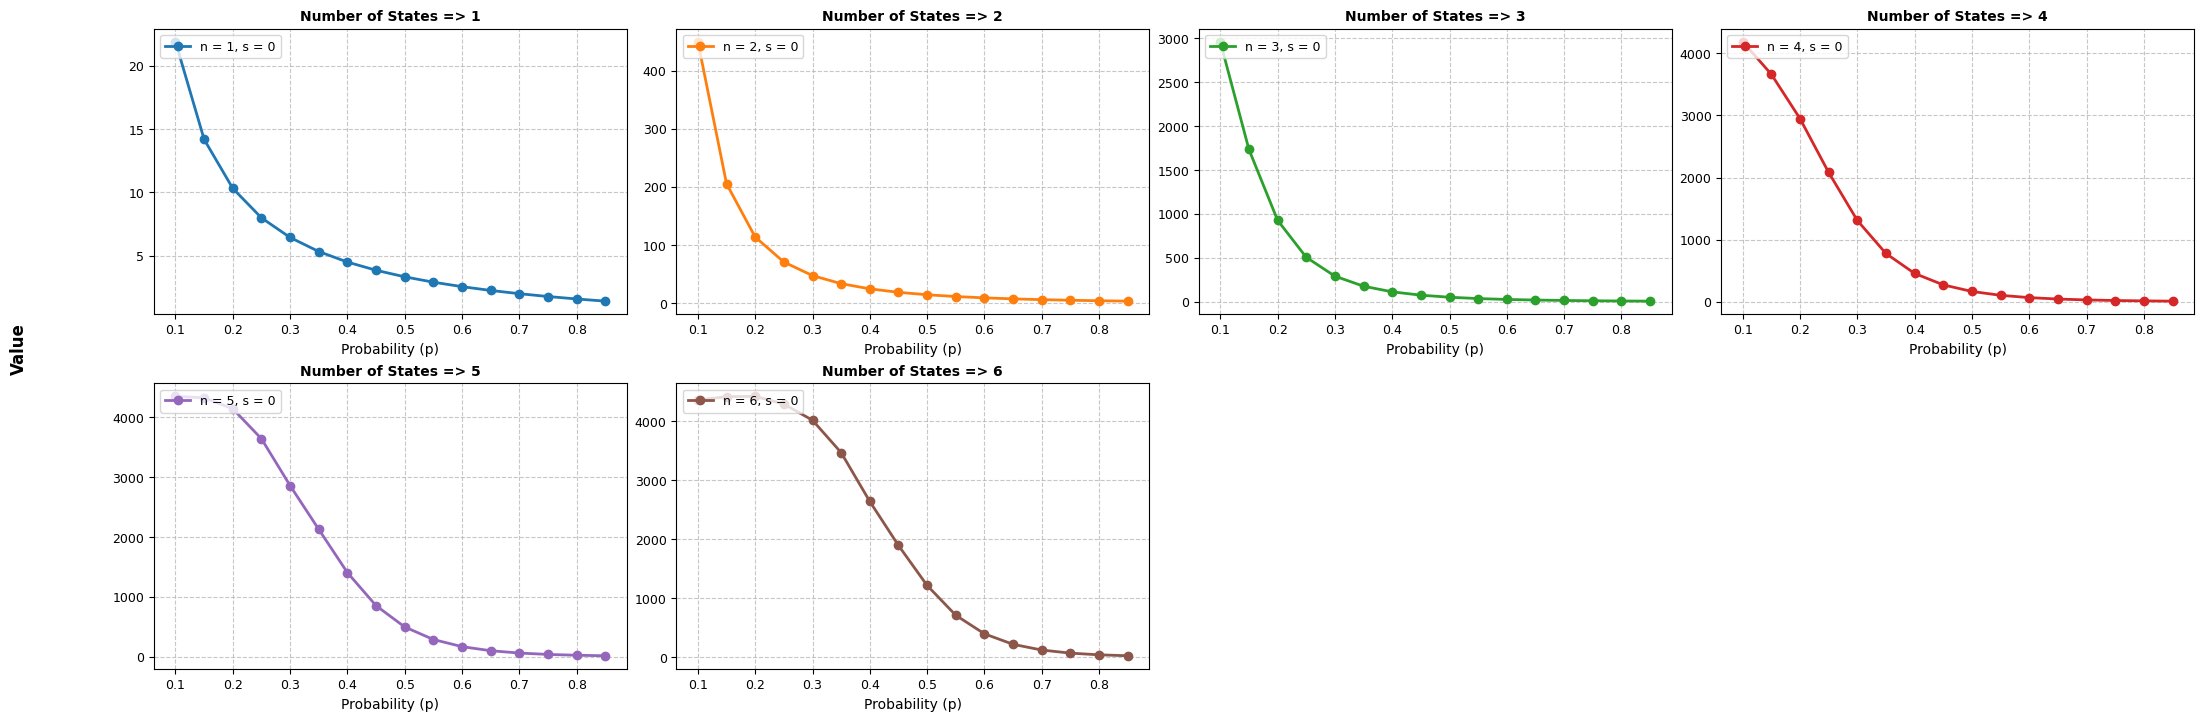

In [189]:
# MSS > Value function
results[plt_method]['mss_value_function_range_probability'] = plt_obj.mss_value_function_range_probability(range_n, range_p, c, k, alpha, gamma, _threshold, _epsilon, _verbose=False)
MSSPlots().subplots_for_number_of_states(results[plt_method]['mss_value_function_range_probability'], sharey=False)

In [190]:
# MSS > Analytical value function
results[plt_method]['mss_analytical_value_function_range_probability'] = plt_obj.mss_analytical_value_function_range_probability(range_n, range_p, c, k)

RecursionError: maximum recursion depth exceeded

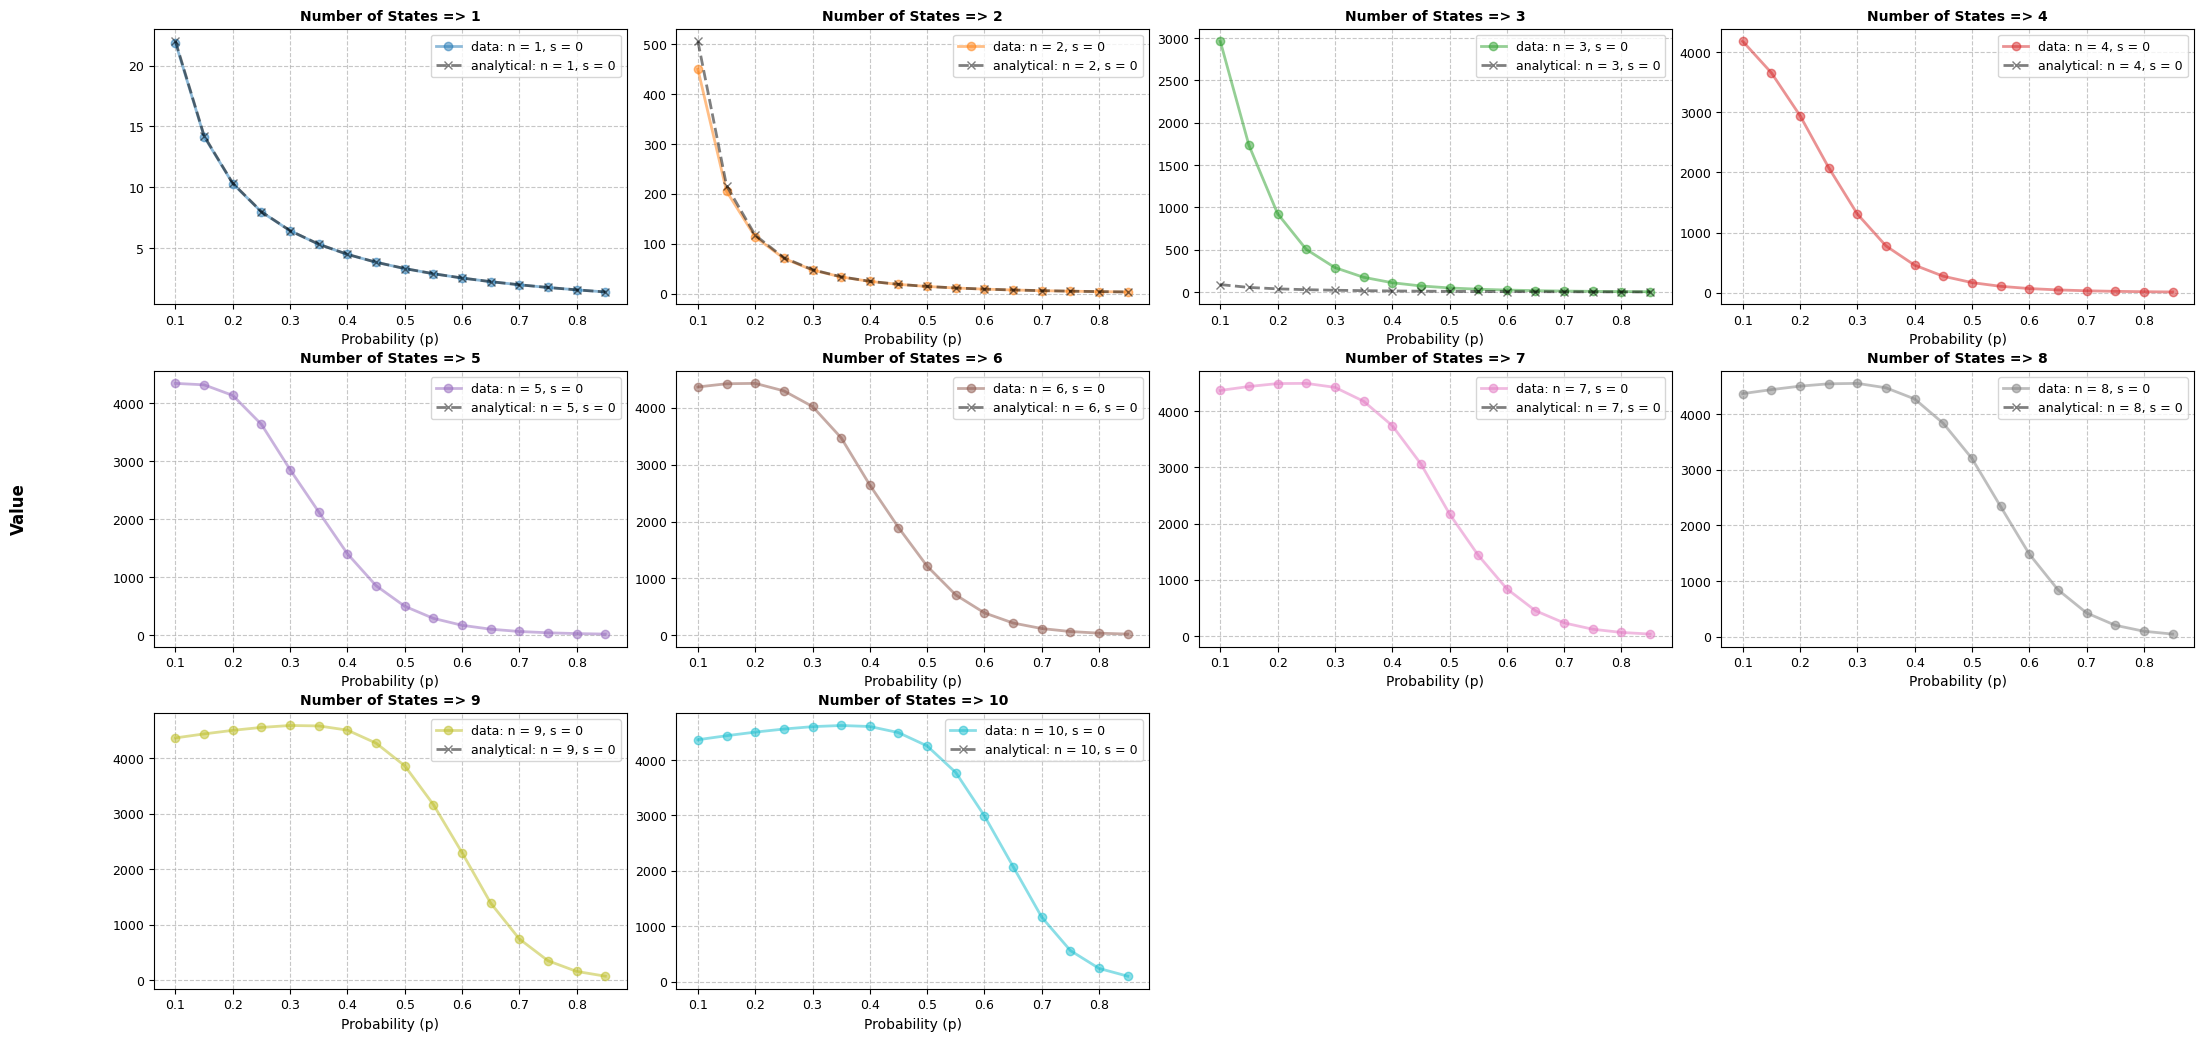

In [136]:
MSSPlots().compare_data_and_analytical(
    data=results[plt_method]['mss_value_function_range_probability'], 
    data_analytical=results[plt_method]['mss_analytical_value_function_range_probability'], 
    sharey=False, 
    plot_only_first_state=True
)

## Value at Risk

## Conditional Value at Risk

## Mean-variance

## Cumulative Distribution Function